In [1]:
import pandas as pd

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing import sequence

In [2]:
if tf.test.gpu_device_name():
    print("GPU device found")
else:
    print("No GPU device found")

No GPU device found


In [4]:
df_fake = pd.read_csv("Fake.csv")
df_true = pd.read_csv("True.csv")

In [5]:
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [6]:
df_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [7]:
df_fake["class"] = 0
df_true["class"] = 1

In [8]:
df_fake.shape, df_true.shape

((23481, 5), (21417, 5))

In [9]:
# Removing last 10 rows for manual testing
df_fake_manual_testing = df_fake.tail(10)
for i in range(23480,23470,-1):
    df_fake.drop([i], axis = 0, inplace = True)
    
    
df_true_manual_testing = df_true.tail(10)
for i in range(21416,21406,-1):
    df_true.drop([i], axis = 0, inplace = True)

In [10]:
df_fake.shape, df_true.shape

((23471, 5), (21407, 5))

In [11]:
df_fake_manual_testing["class"] = 0
df_true_manual_testing["class"] = 1

C:\Users\farza\AppData\Local\Temp\ipykernel_44780\860779283.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fake_manual_testing["class"] = 0
C:\Users\farza\AppData\Local\Temp\ipykernel_44780\860779283.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_true_manual_testing["class"] = 1


In [12]:
df_fake_manual_testing.head(10)

,title,text,subject,date,class
23471,Seven Iranians freed in the prisoner swap have...,"21st Century Wire says This week, the historic...",Middle-east,"January 20, 2016",0
23472,#Hashtag Hell & The Fake Left,By Dady Chery and Gilbert MercierAll writers ...,Middle-east,"January 19, 2016",0
23473,Astroturfing: Journalist Reveals Brainwashing ...,Vic Bishop Waking TimesOur reality is carefull...,Middle-east,"January 19, 2016",0
23474,The New American Century: An Era of Fraud,Paul Craig RobertsIn the last years of the 20t...,Middle-east,"January 19, 2016",0
23475,Hillary Clinton: ‘Israel First’ (and no peace ...,Robert Fantina CounterpunchAlthough the United...,Middle-east,"January 18, 2016",0
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0
23480,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016",0


In [13]:
df_true_manual_testing.head(10)

,title,text,subject,date,class
21407,"Mata Pires, owner of embattled Brazil builder ...","SAO PAULO (Reuters) - Cesar Mata Pires, the ow...",worldnews,"August 22, 2017",1
21408,"U.S., North Korea clash at U.N. forum over nuc...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1
21409,"U.S., North Korea clash at U.N. arms forum on ...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1
21410,Headless torso could belong to submarine journ...,COPENHAGEN (Reuters) - Danish police said on T...,worldnews,"August 22, 2017",1
21411,North Korea shipments to Syria chemical arms a...,UNITED NATIONS (Reuters) - Two North Korean sh...,worldnews,"August 21, 2017",1
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",1


In [14]:
df_manual_testing = pd.concat([df_fake_manual_testing,df_true_manual_testing], axis = 0)
df_manual_testing.to_csv("manual_testing.csv")

## Merging two files

In [15]:
df_merge = pd.concat([df_fake, df_true], axis =0 )
df_merge.head(10)

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017",0
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017",0
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017",0
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017",0
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017",0


In [16]:
df_merge.columns

Index(['title', 'text', 'subject', 'date', 'class'], dtype='object')

In [17]:
data = df_merge.drop(["title", "subject","date"], axis = 1)

In [18]:
data.isnull().sum()

text     0
class    0
dtype: int64

In [19]:
data = data.sample(frac = 1)

In [20]:
data.head()

,text,class
17473,"COX S BAZAR, Bangladesh (Reuters) - Wild eleph...",1
17282,WASHINGTON (Reuters) - After years of focusing...,1
1058,SAN FRANCISCO (Reuters) - Twitter Inc (TWTR.N)...,1
20606,Wake up world! There is a movement by the Left...,0
5942,(Reuters) - Highlights of the day for U.S. Pre...,1


In [21]:
data.reset_index(inplace = True)
data.drop(["index"], axis = 1, inplace = True)

In [22]:
data.columns

Index(['text', 'class'], dtype='object')

In [23]:
data.head()

,text,class
0,"COX S BAZAR, Bangladesh (Reuters) - Wild eleph...",1
1,WASHINGTON (Reuters) - After years of focusing...,1
2,SAN FRANCISCO (Reuters) - Twitter Inc (TWTR.N)...,1
3,Wake up world! There is a movement by the Left...,0
4,(Reuters) - Highlights of the day for U.S. Pre...,1


In [24]:
data.tail()

,text,class
44873,"KANSAS CITY, Mo. (Reuters) - Missouri lawmaker...",1
44874,HOUSTON (Reuters) - President-elect Donald Tru...,1
44875,Though they are officially non-profit organi...,0
44876,BERLIN (Reuters) - Germany s Free Democrats (F...,1
44877,,0


In [25]:
import re
import unicodedata
from bs4 import BeautifulSoup

# FOR STEMMING AND REMOVING STOP WORDS
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer   
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk.tag import pos_tag
from nltk.tokenize import word_tokenize

In [26]:
nltk.download('stopwords')
#### CACHING THE STOP WORDS HELPS IN FASTENING THE REMOVAL OF THE STOP WORDS
cachedStopWords = stopwords.words("english")
nltk.download('wordnet')
nltk.download('words')
nltk.download('averaged_perceptron_tagger')

lemmatizer=WordNetLemmatizer()
corpus_words = set(nltk.corpus.words.words())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\farza\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\farza\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\farza\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\farza\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [27]:
CONTRACTION_MAP = {"ain't": "is not","aren't": "are not","can't": "cannot","can't've": "cannot have","'cause": "because","could've": "could have","couldn't": "could not","couldn't've": "could not have","didn't": "did not","doesn't": "does not","don't": "do not","hadn't": "had not","hadn't've": "had not have","hasn't": "has not","haven't": "have not","he'd": "he would","he'd've": "he would have","he'll": "he will","he'll've": "he he will have","he's": "he is","how'd": "how did","how'd'y": "how do you","how'll": "how will","how's": "how is","I'd": "I would","I'd've": "I would have","I'll": "I will","I'll've": "I will have","I'm": "I am","I've": "I have","i'd": "i would","i'd've": "i would have","i'll": "i will","i'll've": "i will have","i'm": "i am","i've": "i have","isn't": "is not","it'd": "it would","it'd've": "it would have","it'll": "it will","it'll've": "it will have","it's": "it is","let's": "let us","ma'am": "madam","mayn't": "may not","might've": "might have","mightn't": "might not","mightn't've": "might not have","must've": "must have","mustn't": "must not","mustn't've": "must not have","needn't": "need not","needn't've": "need not have","o'clock": "of the clock","oughtn't": "ought not","oughtn't've": "ought not have","shan't": "shall not","sha'n't": "shall not","shan't've": "shall not have","she'd": "she would","she'd've": "she would have","she'll": "she will","she'll've": "she will have","she's": "she is","should've": "should have","shouldn't": "should not","shouldn't've": "should not have","so've": "so have","so's": "so as","that'd": "that would","that'd've": "that would have","that's": "that is","there'd": "there would","there'd've": "there would have","there's": "there is","they'd": "they would","they'd've": "they would have","they'll": "they will","they'll've": "they will have","they're": "they are","they've": "they have","to've": "to have","wasn't": "was not","we'd": "we would","we'd've": "we would have","we'll": "we will","we'll've": "we will have","we're": "we are","we've": "we have","weren't": "were not","what'll": "what will","what'll've": "what will have","what're": "what are","what's": "what is","what've": "what have","when's": "when is","when've": "when have","where'd": "where did","where's": "where is","where've": "where have","who'll": "who will","who'll've": "who will have","who's": "who is","who've": "who have","why's": "why is","why've": "why have","will've": "will have","won't": "will not","won't've": "will not have","would've": "would have","wouldn't": "would not","wouldn't've": "would not have","y'all": "you all","y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have","you'd": "you would","you'd've": "you would have","you'll": "you will","you'll've": "you will have","you're": "you are","you've": "you have"}

In [28]:
def cleanData(data, text_column):
    # Helper functions
    def removeAscentedCharacters(text):
        return unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')

    def expandContractions(text, contraction_mapping):
        contractions_pattern = re.compile('({})'.format('|'.join(contraction_mapping.keys())), flags=re.IGNORECASE|re.DOTALL)
        def expand_match(contraction):
            match = contraction.group(0)
            expanded_contraction = contraction_mapping.get(match.lower())
            return expanded_contraction
        expanded_text = contractions_pattern.sub(expand_match, text)
        return re.sub("'", "", expanded_text)

    def removeIC(text):
        return text.strip('"')

    def remove_tags(text):
        return BeautifulSoup(text, "html.parser").get_text()

    def removeLinks(text):
        return re.sub(r'http\S+', '', text)

    def removeSpecialCharacters(text):
        return re.sub(r'[^a-zA-Z0-9\s]', '', text)

    def removeSpaces(text):
        return " ".join(text.split())
    
    def convertToLowercase(text):
        return text.lower()
    
    def removeStopWords(text):
        stop_words = set(stopwords.words('english'))
        word_tokens = word_tokenize(text)
        filtered_sentence = [w for w in word_tokens if not w.lower() in stop_words]
        return ' '.join(filtered_sentence)

    # Apply cleaning functions to the text column
    data[text_column] = data[text_column].apply(removeAscentedCharacters)
    data[text_column] = data[text_column].apply(expandContractions, contraction_mapping=CONTRACTION_MAP)
    data[text_column] = data[text_column].apply(removeIC)
    data[text_column] = data[text_column].apply(remove_tags)
    data[text_column] = data[text_column].apply(removeLinks)
    data[text_column] = data[text_column].apply(removeSpecialCharacters)
    data[text_column] = data[text_column].apply(removeSpaces)
    data[text_column] = data[text_column].apply(convertToLowercase)
    data[text_column] = data[text_column].apply(removeStopWords)

    return data

In [29]:
cleaned_data = cleanData(data, 'text')

C:\Users\farza\AppData\Local\Temp\ipykernel_44780\1436793348.py:19: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  return BeautifulSoup(text, "html.parser").get_text()
C:\Users\farza\AppData\Local\Temp\ipykernel_44780\1436793348.py:19: MarkupResemblesLocatorWarning: The input looks more like a URL than markup. You may want to use an HTTP client like requests to get the document behind the URL, and feed that document to Beautiful Soup.
  return BeautifulSoup(text, "html.parser").get_text()


In [30]:
cleaned_data.head()

,text,class
0,cox bazar bangladesh reuters wild elephants tr...,1
1,washington reuters years focusing divided iraq...,1
2,san francisco reuters twitter inc twtrn said t...,1
3,wake world movement left remove god lives one ...,0
4,reuters highlights day us president donald tru...,1


EDA

In [31]:
#Visualization libraries
import matplotlib.pyplot as plt 
from matplotlib import rcParams
import seaborn as sns
from textblob import TextBlob
from plotly import tools
import plotly.graph_objs as go
from plotly.offline import iplot
%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 5]
import cufflinks as cf
cf.go_offline()
cf.set_config_file(offline=False, world_readable=True)

In [32]:
df_merge.head()

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


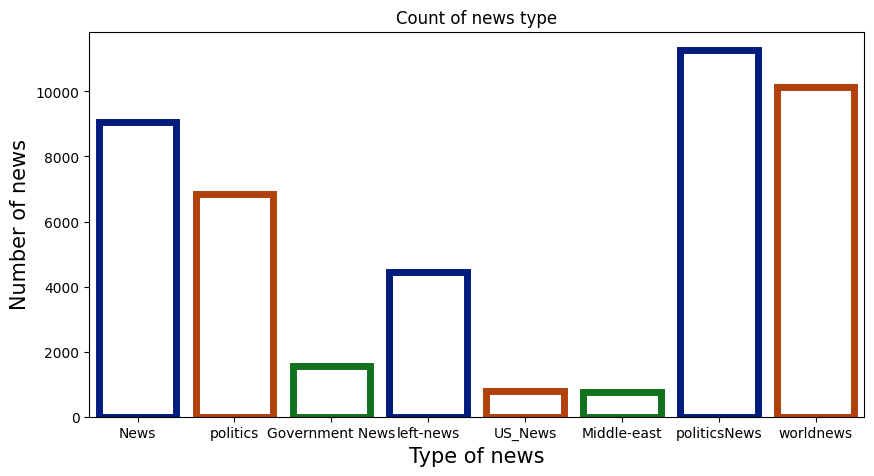

In [33]:
#Plotting the frequency plot
ax = sns.countplot(x="subject", data=df_merge,
                   facecolor=(0, 0, 0, 0),
                   linewidth=5,
                   edgecolor=sns.color_palette("dark", 3))

#Setting labels and font size
ax.set(xlabel='Type of news', ylabel='Number of news',title='Count of news type')
ax.xaxis.get_label().set_fontsize(15)
ax.yaxis.get_label().set_fontsize(15)

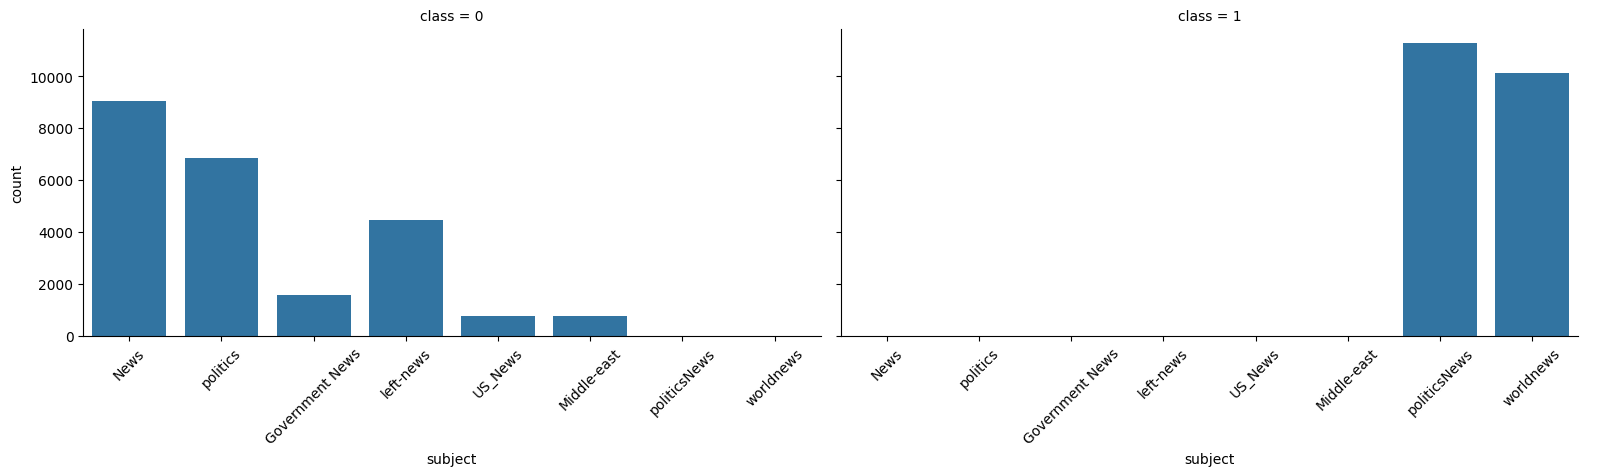

In [34]:
g = sns.catplot(x="subject", col="class",
                data=df_merge, kind="count",
                height=4, aspect=2)

#Rotating the xlabels
g.set_xticklabels(rotation=45)

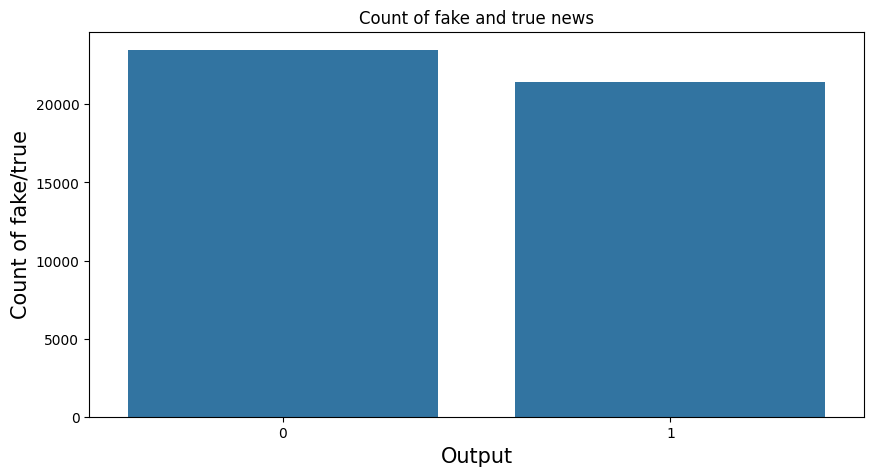

In [35]:
ax=sns.countplot(x="class", data=df_merge)

#Setting labels and font size
ax.set(xlabel='Output', ylabel='Count of fake/true',title='Count of fake and true news')
ax.xaxis.get_label().set_fontsize(15)
ax.yaxis.get_label().set_fontsize(15)

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X = cleaned_data['text']
y = cleaned_data['class']

In [38]:
X_train, X_remaining, y_train, y_remaining = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

In [39]:
X_val, X_test, y_val, y_test = train_test_split(X_remaining, y_remaining, stratify=y_remaining, test_size=0.5, random_state=42)

In [40]:
!pip install transformers

In [41]:
from transformers import DistilBertTokenizer, TFDistilBertModel
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = TFDistilBertModel.from_pretrained("distilbert-base-uncased")

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


In [42]:
import tensorflow as tf

In [43]:
MAX_LENGTH = 128
def batch_encode(tokenizer, texts, batch_size=256, max_length=MAX_LENGTH):
    
    
    input_ids = []
    attention_mask = []
    
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer.batch_encode_plus(batch,
                                             max_length=max_length,
                                             padding='max_length', 
                                             truncation=True,
                                             return_attention_mask=True,
                                             return_token_type_ids=False
                                             )
        input_ids.extend(inputs['input_ids'])
        attention_mask.extend(inputs['attention_mask'])
    
    
    return tf.convert_to_tensor(input_ids), tf.convert_to_tensor(attention_mask)

In [44]:
X_train_ids, X_train_attention = batch_encode(tokenizer, X_train.tolist())
X_train_ids

<tf.Tensor: shape=(31414, 128), dtype=int32, numpy=
array([[  101,  2280,  4895, ...,  2451,  2234,   102],
       [  101,  4461,  2343, ...,  3633,  2163,   102],
       [  101,  2899, 26665, ..., 10528,  2975,   102],
       ...,
       [  101,  4406, 16939, ...,  2094,  2243,   102],
       [  101, 11096, 26665, ...,     0,     0,     0],
       [  101,  3350,  3936, ...,  4138,  2331,   102]])>

In [45]:
X_valid_ids, X_valid_attention = batch_encode(tokenizer, X_val.tolist())

# Encode X_test
X_test_ids, X_test_attention = batch_encode(tokenizer, X_test.tolist())

In [46]:
from transformers import DistilBertConfig

DISTILBERT_DROPOUT = 0.2
DISTILBERT_ATT_DROPOUT = 0.2
 
# Configure DistilBERT's initialization
config = DistilBertConfig(dropout=DISTILBERT_DROPOUT, 
                          attention_dropout=DISTILBERT_ATT_DROPOUT, 
                          output_hidden_states=True)
                          
# The bare, pre-trained DistilBERT transformer model outputting raw hidden-states 
# and without any specific head on top.
distilBERT = TFDistilBertModel.from_pretrained('distilbert-base-uncased', config=config)

# Make DistilBERT layers untrainable
for layer in distilBERT.layers:
    layer.trainable = False

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


In [47]:
import matplotlib.pyplot as plt
from keras.models import Sequential, Model
from keras.layers import Dense, LSTM, Embedding, Dropout, GRU, Input, Conv1D, MaxPool1D, GlobalMaxPooling1D, Flatten, concatenate, SpatialDropout1D, GlobalAveragePooling1D
from keras.constraints import MaxNorm

In [48]:
from sklearn.metrics import classification_report,accuracy_score,f1_score, precision_recall_fscore_support

In [49]:
import math
import tensorflow as tf
import keras

# Model

In [50]:
MAX_LENGTH = 128
LAYER_DROPOUT = 0.2
LEARNING_RATE = 1e-4
RANDOM_STATE = 42

def custom_drc(transformer, max_length=MAX_LENGTH):
    
    
    weight_initializer = tf.keras.initializers.GlorotNormal(seed=RANDOM_STATE) 
    
    
    input_ids_layer1 = tf.keras.layers.Input(shape=(max_length,), 
                                            name='input_ids', 
                                            dtype='int32')
    input_attention_layer1 = tf.keras.layers.Input(shape=(max_length,), 
                                                  name='input_attention', 
                                                  dtype='int32')
    
    
    last_hidden_state1 = transformer([input_ids_layer1, input_attention_layer1])[0]
    
    #model1
    dense1_1 = Dense(128, activation="relu")(last_hidden_state1)
    drop1_1 = Dropout(0.2)(dense1_1)
    dense1_2 = Dense(64, activation="relu")(drop1_1)
    flat1 = Flatten()(dense1_2)
    drop1_2 = Dropout(0.2)(flat1)
    out1 = output = Dense(1, activation='sigmoid', kernel_initializer=weight_initializer, kernel_constraint=None, bias_initializer='zeros')(drop1_2)
    
    
    
    #model2
    gru_layer5_1 = GRU(128, activation='tanh', return_sequences=True)(last_hidden_state1) 
    drop5_1 = Dropout(0.5)(gru_layer5_1)
    lstm_layer5 = LSTM(64, activation='tanh', return_sequences=True)(drop5_1)
    drop5_2 = Dropout(0.5)(lstm_layer5)
    gru_layer5_2 = GRU(32, activation='tanh')(drop5_2)
    drop5_3 = Dropout(0.5)(gru_layer5_2)
    out2 = Dense(1, activation='sigmoid', kernel_initializer=weight_initializer, kernel_constraint=None, bias_initializer='zeros')(drop5_3)
    
    #model3
    max_length = None
                 
    conv1 = Conv1D(filters=128, kernel_size=4, activation='relu', 
               kernel_constraint= MaxNorm( max_value=3, axis=[0,1]))(last_hidden_state1)
    pool1 = MaxPool1D(pool_size=2, strides=2)(conv1)
    flat3 = Flatten()(pool1)
    drop6 = Dropout(0.4)(flat3)
    dense3 = Dense(32, activation='relu')(drop6)
    drop7 = Dropout(0.4)(dense3)
    out3 = Dense(1, activation='sigmoid', kernel_initializer=weight_initializer, kernel_constraint=None, bias_initializer='zeros')(drop7)
    
    merge = concatenate([out1, out2, out3])
    
    outputs = Dense(2, activation='softmax')(merge)
    
    model = Model(inputs=[input_ids_layer1, input_attention_layer1], outputs=outputs)
    
    model.compile( loss='sparse_categorical_crossentropy', optimizer= tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),  metrics=['accuracy'])
    model.summary()
    return model

In [51]:
drc_model = custom_drc(distilBERT, max_length=128)

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_ids (InputLayer)         [(None, 128)]        0           []                               
                                                                                                  
 input_attention (InputLayer)   [(None, 128)]        0           []                               
                                                                                                  
 tf_distil_bert_model_1 (TFDist  TFBaseModelOutput(l  66362880   ['input_ids[0][0]',              
 ilBertModel)                   ast_hidden_state=(N               'input_attention[0][0]']        
                                one, 128, 768),                                                   
                                 hidden_states=((No                                           

In [52]:
EPOCHS =50 
BATCH_SIZE = 10
NUM_STEPS = len(X_train.index) // BATCH_SIZE

# Train the model
train_history4 = drc_model.fit(
    x = [X_train_ids, X_train_attention],
    y = y_train.to_numpy(),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    steps_per_epoch = NUM_STEPS,
    validation_data = ([X_valid_ids, X_valid_attention], y_val.to_numpy()),
    
)

Epoch 1/50


: 

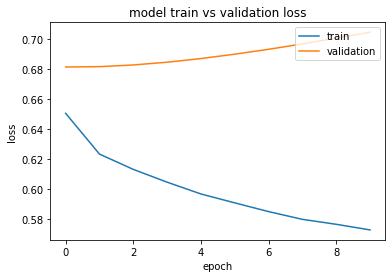

In [40]:
plt.plot(train_history4.history['loss'])
plt.plot(train_history4.history['val_loss'])
plt.title('model train vs validation loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show() 

In [41]:
y_predict = drc_model.predict([X_test_ids, X_test_attention]).argmax(axis=-1)
y_pr = [int(x+0.5) for x in y_predict]

In [35]:
F1 = precision_recall_fscore_support(Y_test, y_pr, average='micro')
F1

(0.6646039603960396, 0.6646039603960396, 0.6646039603960396, None)

In [42]:
classification_report(Y_test, y_pr)

C:\Users\usama\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\usama\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\usama\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


'              precision    recall  f1-score   support\n\n           0       0.50      1.00      0.67       404\n           1       0.00      0.00      0.00       404\n\n    accuracy                           0.50       808\n   macro avg       0.25      0.50      0.33       808\nweighted avg       0.25      0.50      0.33       808\n'

In [31]:
y_predict = drc_model.predict([X_test_ids, X_test_attention])

In [34]:
y_pr = [int(x+0.5) for x in y_predict]

In [37]:
F1 = precision_recall_fscore_support(Y_test, y_pr, average='micro')
F1

(0.777027027027027, 0.777027027027027, 0.777027027027027, None)

In [38]:
classification_report(Y_test, y_pr)

'              precision    recall  f1-score   support\n\n           0       0.75      0.82      0.79       296\n           1       0.80      0.73      0.77       296\n\n    accuracy                           0.78       592\n   macro avg       0.78      0.78      0.78       592\nweighted avg       0.78      0.78      0.78       592\n'

In [39]:
MAX_LENGTH = 128
LAYER_DROPOUT = 0.2
LEARNING_RATE = 1e-4
RANDOM_STATE = 42

def drc_1(transformer, max_length=MAX_LENGTH):
    
    
    weight_initializer = tf.keras.initializers.GlorotNormal(seed=RANDOM_STATE) 
    
    
    input_ids_layer1 = tf.keras.layers.Input(shape=(max_length,), 
                                            name='input_ids', 
                                            dtype='int32')
    input_attention_layer1 = tf.keras.layers.Input(shape=(max_length,), 
                                                  name='input_attention', 
                                                  dtype='int32')
    
    
    last_hidden_state1 = transformer([input_ids_layer1, input_attention_layer1])[0]
    
    #model1
    dense1_1 = Dense(64, activation="relu")(last_hidden_state1)
    drop1_1 = Dropout(0.2)(dense1_1)
    dense1_2 = Dense(32, activation="relu")(drop1_1)
    flat1 = Flatten()(dense1_2)
    drop1_2 = Dropout(0.2)(flat1)
    out1 = output = Dense(1, activation='sigmoid', kernel_initializer=weight_initializer, kernel_constraint=None, bias_initializer='zeros')(drop1_2)
    
    
    
    #model2
    gru_layer5_1 = GRU(128, activation='tanh', return_sequences=True)(last_hidden_state1) 
    drop5_1 = Dropout(0.5)(gru_layer5_1)
    lstm_layer5 = LSTM(128, activation='tanh', return_sequences=True)(drop5_1)
    drop5_2 = Dropout(0.5)(lstm_layer5)
    gru_layer5_2 = GRU(64, activation='tanh')(drop5_2)
    drop5_3 = Dropout(0.5)(gru_layer5_2)
    out2 = Dense(1, activation='sigmoid', kernel_initializer=weight_initializer, kernel_constraint=None, bias_initializer='zeros')(drop5_3)
    
    #model3
    max_length = None
    filters = 100 
    kernel_size = 3
  
                 
    conv9_1 = Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', 
               kernel_constraint= MaxNorm( max_value=3, axis=[0,1]))(last_hidden_state1)
    pool9_1 = MaxPool1D(pool_size=2, strides=2)(conv9_1)
    flat9_1 = Flatten()(pool9_1)
    drop9_1 = Dropout(0.5)(flat9_1)
    dense9_1 = Dense(10, activation='relu')(drop9_1)
    drop9_2 = Dropout(0.5)(dense9_1)
    out3 = Dense(1, activation='sigmoid', kernel_initializer=weight_initializer, kernel_constraint=None, bias_initializer='zeros')(drop9_2)
    
    merge = concatenate([out1, out2, out3])
    
    outputs = Dense(1, activation='sigmoid')(merge)
    
    model = Model(inputs=[input_ids_layer1, input_attention_layer1], outputs=outputs)
    
    model.compile( loss='binary_crossentropy', optimizer= tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),  metrics=['accuracy'])
    model.summary()
    return model

In [41]:
drc_m = drc(distilBERT, max_length=128)

Model: "model_5"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_ids (InputLayer)          [(None, 128)]        0                                            
__________________________________________________________________________________________________
input_attention (InputLayer)    [(None, 128)]        0                                            
__________________________________________________________________________________________________
tf_distil_bert_model_1 (TFDisti TFBaseModelOutput(la 66362880    input_ids[0][0]                  
                                                                 input_attention[0][0]            
__________________________________________________________________________________________________
gru_10 (GRU)                    (None, 128, 128)     344832      tf_distil_bert_model_1[5][7

In [42]:
EPOCHS =35 
BATCH_SIZE = 50
NUM_STEPS = len(X_train.index) // BATCH_SIZE

# Train the model
train_history4 = drc_m.fit(
    x = [X_train_ids, X_train_attention],
    y = Y_train.to_numpy(),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    steps_per_epoch = NUM_STEPS,
    validation_data = ([X_valid_ids, X_valid_attention], Y_eval.to_numpy()),
    
)

Epoch 1/35
170/170 [==============================] - 89s 474ms/step - loss: 0.5300 - accuracy: 0.7562 - val_loss: 0.3573 - val_accuracy: 0.9052
Epoch 2/35
170/170 [==============================] - 77s 454ms/step - loss: 0.4823 - accuracy: 0.7824 - val_loss: 0.3533 - val_accuracy: 0.8776
Epoch 3/35
170/170 [==============================] - 77s 455ms/step - loss: 0.4296 - accuracy: 0.8282 - val_loss: 0.3238 - val_accuracy: 0.9016
Epoch 4/35
170/170 [==============================] - 77s 456ms/step - loss: 0.4138 - accuracy: 0.8366 - val_loss: 0.3442 - val_accuracy: 0.8715
Epoch 5/35
170/170 [==============================] - 77s 455ms/step - loss: 0.4055 - accuracy: 0.8501 - val_loss: 0.3158 - val_accuracy: 0.8920
Epoch 6/35
170/170 [==============================] - 77s 455ms/step - loss: 0.3910 - accuracy: 0.8526 - val_loss: 0.3199 - val_accuracy: 0.8860
Epoch 7/35
170/170 [==============================] - 78s 456ms/step - loss: 0.3815 - accuracy: 0.8608 - val_loss: 0.3082 - val_ac

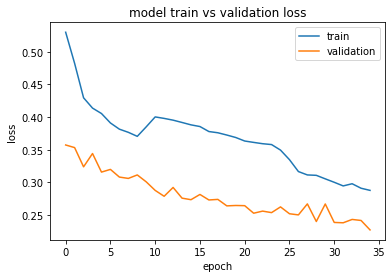

In [43]:
plt.plot(train_history4.history['loss'])
plt.plot(train_history4.history['val_loss'])
plt.title('model train vs validation loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show() 

In [44]:
y_pred = drc_m.predict([X_test_ids, X_test_attention])
y_pr = [int(x+0.5) for x in y_pred]
classification_report(Y_test, y_pr)

'              precision    recall  f1-score   support\n\n           0       0.73      0.88      0.80       296\n           1       0.85      0.68      0.76       296\n\n    accuracy                           0.78       592\n   macro avg       0.79      0.78      0.78       592\nweighted avg       0.79      0.78      0.78       592\n'

In [45]:
F1 = precision_recall_fscore_support(Y_test, y_pr, average='micro')
F1

(0.7804054054054054, 0.7804054054054054, 0.7804054054054054, None)

In [51]:
MAX_LENGTH = 128
LAYER_DROPOUT = 0.2
LEARNING_RATE = 1e-4
RANDOM_STATE = 42

def drc_12(transformer, max_length=MAX_LENGTH):
    
    
    weight_initializer = tf.keras.initializers.GlorotNormal(seed=RANDOM_STATE) 
    
    
    input_ids_layer1 = tf.keras.layers.Input(shape=(max_length,), 
                                            name='input_ids', 
                                            dtype='int32')
    input_attention_layer1 = tf.keras.layers.Input(shape=(max_length,), 
                                                  name='input_attention', 
                                                  dtype='int32')
    
    
    last_hidden_state1 = transformer([input_ids_layer1, input_attention_layer1])[0]
    
    #model1
    dense1_1 = Dense(64, activation="relu")(last_hidden_state1)
    drop1_1 = Dropout(0.2)(dense1_1)
    dense1_2 = Dense(32, activation="relu")(drop1_1)
    flat1 = Flatten()(dense1_2)
    drop1_2 = Dropout(0.2)(flat1)
    out1 = output = Dense(1, activation='sigmoid', kernel_initializer=weight_initializer, kernel_constraint=None, bias_initializer='zeros')(drop1_2)
    
    
    
    #model2
    gru_layer5_1 = GRU(128, activation='tanh', return_sequences=True)(last_hidden_state1) 
    drop5_1 = Dropout(0.5)(gru_layer5_1)
    lstm_layer5 = LSTM(128, activation='tanh', return_sequences=True)(drop5_1)
    drop5_2 = Dropout(0.5)(lstm_layer5)
    gru_layer5_2 = GRU(64, activation='tanh')(drop5_2)
    drop5_3 = Dropout(0.5)(gru_layer5_2)
    out2 = Dense(1, activation='sigmoid', kernel_initializer=weight_initializer, kernel_constraint=None, bias_initializer='zeros')(drop5_3)
    
    #model3
    max_length = None
    filters = 100 
    kernel_size = 3
  
                 
    conv9_1 = Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', 
               kernel_constraint= MaxNorm( max_value=3, axis=[0,1]))(last_hidden_state1)
    pool9_1 = MaxPool1D(pool_size=2, strides=2)(conv9_1)
    flat9_1 = Flatten()(pool9_1)
    drop9_1 = Dropout(0.5)(flat9_1)
    dense9_1 = Dense(10, activation='relu')(drop9_1)
    drop9_2 = Dropout(0.5)(dense9_1)
    out3 = Dense(1, activation='sigmoid', kernel_initializer=weight_initializer, kernel_constraint=None, bias_initializer='zeros')(drop9_2)
    
    merge = concatenate([out1, out2, out3])
    
    outputs = Dense(2, activation='softmax')(merge)
    
    model = Model(inputs=[input_ids_layer1, input_attention_layer1], outputs=outputs)
    
    model.compile( loss='sparse_categorical_crossentropy', optimizer= tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),  metrics=['accuracy'])
    model.summary()
    return model

In [52]:
mmd = drc_12(distilBERT, max_length=128)

Model: "model_8"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_ids (InputLayer)          [(None, 128)]        0                                            
__________________________________________________________________________________________________
input_attention (InputLayer)    [(None, 128)]        0                                            
__________________________________________________________________________________________________
tf_distil_bert_model_1 (TFDisti TFBaseModelOutput(la 66362880    input_ids[0][0]                  
                                                                 input_attention[0][0]            
__________________________________________________________________________________________________
gru_16 (GRU)                    (None, 128, 128)     344832      tf_distil_bert_model_1[8][7

In [53]:
EPOCHS =25 
BATCH_SIZE = 50
NUM_STEPS = len(X_train.index) // BATCH_SIZE

# Train the model
train_history4 = mmd.fit(
    x = [X_train_ids, X_train_attention],
    y = Y_train.to_numpy(),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    steps_per_epoch = NUM_STEPS,
    validation_data = ([X_valid_ids, X_valid_attention], Y_eval.to_numpy()),
    
)

Epoch 1/25
170/170 [==============================] - 83s 450ms/step - loss: 0.5235 - accuracy: 0.7564 - val_loss: 0.3429 - val_accuracy: 0.8992
Epoch 2/25
170/170 [==============================] - 75s 440ms/step - loss: 0.4365 - accuracy: 0.8009 - val_loss: 0.3515 - val_accuracy: 0.8523
Epoch 3/25
170/170 [==============================] - 75s 440ms/step - loss: 0.3922 - accuracy: 0.8378 - val_loss: 0.2981 - val_accuracy: 0.8944
Epoch 4/25
170/170 [==============================] - 75s 441ms/step - loss: 0.3746 - accuracy: 0.8488 - val_loss: 0.3235 - val_accuracy: 0.8703
Epoch 5/25
170/170 [==============================] - 75s 441ms/step - loss: 0.3642 - accuracy: 0.8541 - val_loss: 0.2792 - val_accuracy: 0.9016
Epoch 6/25
170/170 [==============================] - 75s 442ms/step - loss: 0.3494 - accuracy: 0.8636 - val_loss: 0.2692 - val_accuracy: 0.9076
Epoch 7/25
170/170 [==============================] - 75s 442ms/step - loss: 0.3394 - accuracy: 0.8664 - val_loss: 0.2498 - val_ac

In [55]:
y_pred = mmd.predict([X_test_ids, X_test_attention]).argmax(axis=-1)
y_pr = [int(x+0.5) for x in y_pred]
classification_report(Y_test, y_pr)

'              precision    recall  f1-score   support\n\n           0       0.77      0.84      0.81       296\n           1       0.83      0.75      0.79       296\n\n    accuracy                           0.80       592\n   macro avg       0.80      0.80      0.80       592\nweighted avg       0.80      0.80      0.80       592\n'

In [56]:
F1 = precision_recall_fscore_support(Y_test, y_pr, average='micro')
F1

(0.7956081081081081, 0.7956081081081081, 0.795608108108108, None)

In [57]:
import tensorflow_addons as tfa

C:\Users\usama\anaconda3\envs\tf-gpu\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.7.0 and strictly below 2.10.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.6.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're using a tested and supported configuration, either change the TensorFlow version or the TensorFlow Addons's version. 
You can find the compatibility matrix in TensorFlow Addon's readme:
https://github.com/tensorflow/addons
  warnings.warn(


In [64]:
MAX_LENGTH = 128
LAYER_DROPOUT = 0.2
LEARNING_RATE = 1e-4
RANDOM_STATE = 42

def drc_123(transformer, max_length=MAX_LENGTH):
    
    
    weight_initializer = tf.keras.initializers.GlorotNormal(seed=RANDOM_STATE) 
    
    
    input_ids_layer1 = tf.keras.layers.Input(shape=(max_length,), 
                                            name='input_ids', 
                                            dtype='int32')
    input_attention_layer1 = tf.keras.layers.Input(shape=(max_length,), 
                                                  name='input_attention', 
                                                  dtype='int32')
    
    
    last_hidden_state1 = transformer([input_ids_layer1, input_attention_layer1])[0]
    
    #model1
    dense1_1 = Dense(64, activation="relu")(last_hidden_state1)
    drop1_1 = Dropout(0.2)(dense1_1)
    dense1_2 = Dense(32, activation="relu")(drop1_1)
    flat1 = Flatten()(dense1_2)
    drop1_2 = Dropout(0.2)(flat1)
    out1 = output = Dense(1, activation='sigmoid', kernel_initializer=weight_initializer, kernel_constraint=None, bias_initializer='zeros')(drop1_2)
    
    
    
    #model2
    gru_layer5_1 = GRU(128, activation='tanh', return_sequences=True)(last_hidden_state1) 
    drop5_1 = Dropout(0.5)(gru_layer5_1)
    lstm_layer5 = LSTM(128, activation='tanh', return_sequences=True)(drop5_1)
    drop5_2 = Dropout(0.5)(lstm_layer5)
    gru_layer5_2 = GRU(64, activation='tanh')(drop5_2)
    drop5_3 = Dropout(0.5)(gru_layer5_2)
    out2 = Dense(1, activation='sigmoid', kernel_initializer=weight_initializer, kernel_constraint=None, bias_initializer='zeros')(drop5_3)
    
    #model3
    max_length = None
    filters = 100 
    kernel_size = 3
  
                 
    conv9_1 = Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', 
               kernel_constraint= MaxNorm( max_value=3, axis=[0,1]))(last_hidden_state1)
    pool9_1 = MaxPool1D(pool_size=2, strides=2)(conv9_1)
    flat9_1 = Flatten()(pool9_1)
    drop9_1 = Dropout(0.5)(flat9_1)
    dense9_1 = Dense(10, activation='relu')(drop9_1)
    drop9_2 = Dropout(0.5)(dense9_1)
    out3 = Dense(1, activation='sigmoid', kernel_initializer=weight_initializer, kernel_constraint=None, bias_initializer='zeros')(drop9_2)
    
    merge = concatenate([out1, out2, out3])
    
    outputs = Dense(1, activation='sigmoid')(merge)
    
    model = Model(inputs=[input_ids_layer1, input_attention_layer1], outputs=outputs)
    
    model.compile( loss=tfa.losses.SigmoidFocalCrossEntropy(), optimizer= tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),  metrics=['accuracy'])
    model.summary()
    return model

In [67]:
model1 = drc_123(distilBERT, max_length=128)

Model: "model_11"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_ids (InputLayer)          [(None, 128)]        0                                            
__________________________________________________________________________________________________
input_attention (InputLayer)    [(None, 128)]        0                                            
__________________________________________________________________________________________________
tf_distil_bert_model_1 (TFDisti TFBaseModelOutput(la 66362880    input_ids[0][0]                  
                                                                 input_attention[0][0]            
__________________________________________________________________________________________________
gru_22 (GRU)                    (None, 128, 128)     344832      tf_distil_bert_model_1[11]

In [68]:
EPOCHS =25 
BATCH_SIZE = 50
NUM_STEPS = len(X_train.index) // BATCH_SIZE

# Train the model
train_history4 = model1.fit(
    x = [X_train_ids, X_train_attention],
    y = Y_train.to_numpy(),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    steps_per_epoch = NUM_STEPS,
    validation_data = ([X_valid_ids, X_valid_attention], Y_eval.to_numpy()),
    
)

Epoch 1/25
170/170 [==============================] - 84s 449ms/step - loss: 0.0521 - accuracy: 0.7547 - val_loss: 0.0321 - val_accuracy: 0.8956
Epoch 2/25
170/170 [==============================] - 74s 438ms/step - loss: 0.0419 - accuracy: 0.7575 - val_loss: 0.0357 - val_accuracy: 0.9088
Epoch 3/25
170/170 [==============================] - 75s 440ms/step - loss: 0.0391 - accuracy: 0.7808 - val_loss: 0.0283 - val_accuracy: 0.9076
Epoch 4/25
170/170 [==============================] - 75s 440ms/step - loss: 0.0376 - accuracy: 0.8111 - val_loss: 0.0303 - val_accuracy: 0.9124
Epoch 5/25
170/170 [==============================] - 75s 440ms/step - loss: 0.0362 - accuracy: 0.8273 - val_loss: 0.0300 - val_accuracy: 0.9172
Epoch 6/25
170/170 [==============================] - 75s 440ms/step - loss: 0.0357 - accuracy: 0.8333 - val_loss: 0.0293 - val_accuracy: 0.9184
Epoch 7/25
170/170 [==============================] - 75s 441ms/step - loss: 0.0348 - accuracy: 0.8359 - val_loss: 0.0303 - val_ac

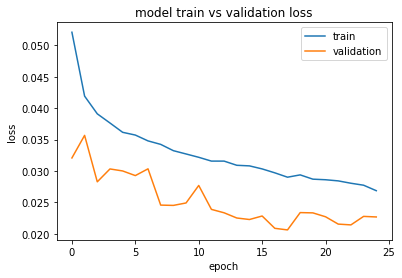

In [71]:
plt.plot(train_history4.history['loss'])
plt.plot(train_history4.history['val_loss'])
plt.title('model train vs validation loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show() 

In [69]:
y_pred = model1.predict([X_test_ids, X_test_attention])
y_pr = [int(x+0.5) for x in y_pred]
classification_report(Y_test, y_pr)

'              precision    recall  f1-score   support\n\n           0       0.69      0.92      0.79       296\n           1       0.88      0.59      0.71       296\n\n    accuracy                           0.76       592\n   macro avg       0.79      0.76      0.75       592\nweighted avg       0.79      0.76      0.75       592\n'

In [70]:
F1 = precision_recall_fscore_support(Y_test, y_pr, average='micro')
F1

(0.7584459459459459, 0.7584459459459459, 0.7584459459459459, None)